<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
## <font color='blue'>Matemática e Estatística Aplicada Para Data Science, Machine Learning e IA</font>
## <font color='blue'>Projeto 6</font>
### <font color='blue'>Modelagem Estatística em Indicadores Socioeconômicos</font>

## Instalando e Carregando os Pacotes

In [1]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
!pip install -q -U watermark

In [2]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import StandardScaler 
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Data Science Academy" 

Author: Data Science Academy



## Carregando e Compreendendo os Dados

In [4]:
# Carregando os dados
df_dsa = pd.read_csv('dataset.csv')

In [5]:
# Shape
df_dsa.shape

(2938, 22)

In [6]:
# Tipos de dados
df_dsa.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
 Population                        float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [7]:
# Amostra dos dados
df_dsa.sample(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
784,Dominican Republic,2001,Developing,71.2,188.0,7,6.13,340.023995,66.0,113,...,71.0,5.59,72.0,2.5,2862.154836,8697126.0,3.8,3.6,0.656,12.3
104,Armenia,2007,Developing,73.5,132.0,1,3.99,44.572200,85.0,1,...,9.0,4.31,88.0,0.1,3138.887300,293356.0,2.0,2.1,0.707,11.7
2770,United Kingdom of Great Britain and Northern I...,2007,Developed,79.5,8.0,4,11.84,0.000000,NaN,1022,...,92.0,8.42,92.0,0.1,NaN,NaN,0.7,0.5,NaN,NaN
1106,Guyana,2015,Developing,66.2,215.0,0,NaN,0.000000,95.0,0,...,92.0,NaN,95.0,0.3,4136.689919,768514.0,5.5,5.3,0.638,10.3
798,Ecuador,2003,Developing,74.4,151.0,8,3.69,18.261833,82.0,0,...,97.0,6.46,87.0,0.3,244.468980,1328961.0,1.5,1.4,0.679,12.6
2212,Samoa,2003,Developing,79.0,169.0,0,4.17,24.997171,83.0,0,...,82.0,4.71,83.0,0.1,197.294170,177662.0,0.2,0.2,0.659,12.3
1243,Iraq,2006,Developing,64.7,249.0,31,0.03,75.257998,59.0,474,...,63.0,3.00,59.0,0.1,2351.812429,27697912.0,5.4,5.1,0.631,10.2
2316,Singapore,2012,Developed,82.5,59.0,0,1.89,6041.858981,97.0,42,...,97.0,4.22,97.0,0.1,54431.161990,NaN,2.2,2.1,0.917,15.4
381,Brunei Darussalam,2002,Developing,74.8,95.0,0,0.13,941.703687,99.0,0,...,99.0,3.40,94.0,0.1,16846.219800,NaN,6.7,6.1,0.820,13.3
1232,Iran (Islamic Republic of),2001,Developing,78.0,146.0,33,0.01,0.000000,94.0,9582,...,95.0,5.20,96.0,0.1,NaN,NaN,7.7,7.8,0.666,11.6


## Ajuste Inicial nos Dados

In [8]:
# Colunas
df_dsa.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', ' Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [9]:
# Criando um novo dataset e ajustando o nome das variáveis
# Observe que estamos desconsiderando algumas variáveis:
# percentage expenditure, under-five deaths e Income composition of resources não estão sendo consideradas
# Essas variáveis não apresentam descrição clara na fonte de dados e por isso estão sendo removidas da análise
df = pd.DataFrame({'country': df_dsa['Country'],
                   'life_expectancy': df_dsa['Life expectancy '],
                   'year': df_dsa['Year'],
                   'status': df_dsa['Status'],
                   'adult_mortality': df_dsa['Adult Mortality'],
                   'inf_death': df_dsa['infant deaths'],
                   'alcohol': df_dsa['Alcohol'],
                   'hepatitisB': df_dsa['Hepatitis B'],
                   'measles': df_dsa['Measles '],
                   'bmi': df_dsa[' BMI '],
                   'polio': df_dsa['Polio'],
                   'diphtheria': df_dsa['Diphtheria '],
                   'hiv': df_dsa[' HIV/AIDS'],
                   'gdp': df_dsa['GDP'],
                   'total_expenditure': df_dsa['Total expenditure'],
                   'thinness_till19': df_dsa[' thinness  1-19 years'],
                   'thinness_till9': df_dsa[' thinness 5-9 years'],
                   'school': df_dsa['Schooling'],
                   'population': df_dsa[' Population']})

In [10]:
# Tipos de dados
df.dtypes

country               object
life_expectancy      float64
year                   int64
status                object
adult_mortality      float64
inf_death              int64
alcohol              float64
hepatitisB           float64
measles                int64
bmi                  float64
polio                float64
diphtheria           float64
hiv                  float64
gdp                  float64
total_expenditure    float64
thinness_till19      float64
thinness_till9       float64
school               float64
population           float64
dtype: object

In [11]:
# Shape
df.shape

(2938, 19)

In [12]:
# Dataset
df.head()

,country,life_expectancy,year,status,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
0,Afghanistan,65.0,2015,Developing,263.0,62,0.01,65.0,1154,19.1,6.0,65.0,0.1,584.259210,8.16,17.2,17.3,10.1,33736494.0
1,Afghanistan,59.9,2014,Developing,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0
2,Afghanistan,59.9,2013,Developing,268.0,66,0.01,64.0,430,18.1,62.0,64.0,0.1,631.744976,8.13,17.7,17.7,9.9,31731688.0
3,Afghanistan,59.5,2012,Developing,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0
4,Afghanistan,59.2,2011,Developing,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0


## Análise Exploratória

In [13]:
# Cria um dicionário com a descrição de cada variável
dsa_df_dict = {
    "country": "País de origem dos dados.",
    "life_expectancy": "Expectativa de vida ao nascer, em anos.",
    "year": "Ano em que os dados foram coletados.",
    "status": "Status de desenvolvimento do país ('Developing' para países em desenvolvimento, 'Developed' para países desenvolvidos).",
    "adult_mortality": "Taxa de mortalidade de adultos entre 15 e 60 anos por 1000 habitantes.",
    "inf_death": "Número de mortes de crianças com menos de 5 anos por 1000 nascidos vivos.",
    "alcohol": "Consumo de álcool per capita (litros de álcool puro por ano).",
    "hepatitisB": "Cobertura de vacinação contra hepatite B em crianças de 1 ano (%).",
    "measles": "Número de casos de sarampo relatados por 1000 habitantes.",
    "bmi": "Índice médio de massa corporal da população adulta.",
    "polio": "Cobertura de vacinação contra poliomielite em crianças de 1 ano (%).",
    "diphtheria": "Cobertura de vacinação contra difteria, tétano e coqueluche (DTP3) em crianças de 1 ano (%).",
    "hiv": "Prevalência de HIV na população adulta (%).",
    "gdp": "Produto Interno Bruto per capita (em dólares americanos).",
    "total_expenditure": "Gasto total em saúde como porcentagem do PIB.",
    "thinness_till19": "Prevalência de magreza em crianças e adolescentes de 10 a 19 anos (%).",
    "thinness_till9": "Prevalência de magreza em crianças de 5 a 9 anos (%).",
    "school": "Número médio de anos de escolaridade.",
    "population": "População total do país."
}

In [14]:
# Agora é só consultar sempre que tiver dúvidas sobre cada variável
dsa_df_dict['life_expectancy']

'Expectativa de vida ao nascer, em anos.'

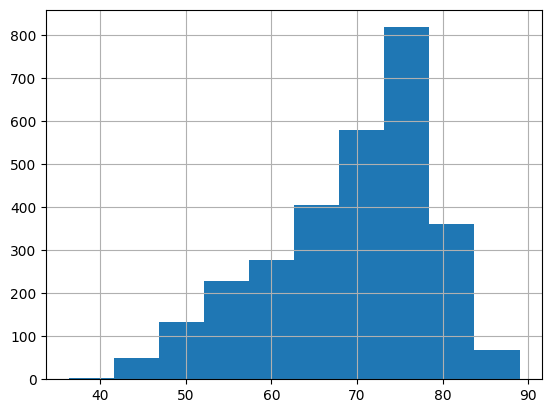

In [15]:
# Plot do histograma da variável alvo (variável quantitativa)
df['life_expectancy'].hist();

In [16]:
# Resumo estatístico (variáveis numéricas)
df.describe()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
count,2928.000000,2938.000000,2928.000000,2938.000000,2744.000000,2385.000000,2938.000000,2904.000000,2919.000000,2919.000000,2938.000000,2490.000000,2712.00000,2904.000000,2904.000000,2775.000000,2.286000e+03
mean,69.224932,2007.518720,164.796448,30.303948,4.602861,80.940461,2419.592240,38.321247,82.550188,82.324084,1.742103,7483.158469,5.93819,4.839704,4.870317,11.992793,1.275338e+07
std,9.523867,4.613841,124.292079,117.926501,4.052413,25.070016,11467.272489,20.044034,23.428046,23.716912,5.077785,14270.169342,2.49832,4.420195,4.508882,3.358920,6.101210e+07
min,36.300000,2000.000000,1.000000,0.000000,0.010000,1.000000,0.000000,1.000000,3.000000,2.000000,0.100000,1.681350,0.37000,0.100000,0.100000,0.000000,3.400000e+01
25%,63.100000,2004.000000,74.000000,0.000000,0.877500,77.000000,0.000000,19.300000,78.000000,78.000000,0.100000,463.935626,4.26000,1.600000,1.500000,10.100000,1.957932e+05
50%,72.100000,2008.000000,144.000000,3.000000,3.755000,92.000000,17.000000,43.500000,93.000000,93.000000,0.100000,1766.947595,5.75500,3.300000,3.300000,12.300000,1.386542e+06
75%,75.700000,2012.000000,228.000000,22.000000,7.702500,97.000000,360.250000,56.200000,97.000000,97.000000,0.800000,5910.806335,7.49250,7.200000,7.200000,14.300000,7.420359e+06
max,89.000000,2015.000000,723.000000,1800.000000,17.870000,99.000000,212183.000000,87.300000,99.000000,99.000000,50.600000,119172.741800,17.60000,27.700000,28.600000,20.700000,1.293859e+09


In [17]:
# Resumo estatístico (variáveis categóricas)
df.describe(include=['object'])

,country,status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


In [18]:
# Resumo estatístico de todas as variáveis
df.describe(include = 'all')

,country,life_expectancy,year,status,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
count,2938,2928.000000,2938.000000,2938,2928.000000,2938.000000,2744.000000,2385.000000,2938.000000,2904.000000,2919.000000,2919.000000,2938.000000,2490.000000,2712.00000,2904.000000,2904.000000,2775.000000,2.286000e+03
unique,193,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,Developing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,16,NaN,NaN,2426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,69.224932,2007.518720,NaN,164.796448,30.303948,4.602861,80.940461,2419.592240,38.321247,82.550188,82.324084,1.742103,7483.158469,5.93819,4.839704,4.870317,11.992793,1.275338e+07
std,NaN,9.523867,4.613841,NaN,124.292079,117.926501,4.052413,25.070016,11467.272489,20.044034,23.428046,23.716912,5.077785,14270.169342,2.49832,4.420195,4.508882,3.358920,6.101210e+07
min,NaN,36.300000,2000.000000,NaN,1.000000,0.000000,0.010000,1.000000,0.000000,1.000000,3.000000,2.000000,0.100000,1.681350,0.37000,0.100000,0.100000,0.000000,3.400000e+01
25%,NaN,63.100000,2004.000000,NaN,74.000000,0.000000,0.877500,77.000000,0.000000,19.300000,78.000000,78.000000,0.100000,463.935626,4.26000,1.600000,1.500000,10.100000,1.957932e+05
50%,NaN,72.100000,2008.000000,NaN,144.000000,3.000000,3.755000,92.000000,17.000000,43.500000,93.000000,93.000000,0.100000,1766.947595,5.75500,3.300000,3.300000,12.300000,1.386542e+06
75%,NaN,75.700000,2012.000000,NaN,228.000000,22.000000,7.702500,97.000000,360.250000,56.200000,97.000000,97.000000,0.800000,5910.806335,7.49250,7.200000,7.200000,14.300000,7.420359e+06


In [19]:
# Função para o plot da relação da variável alvo com alguns atributos
def dsa_get_pairs(data, alvo, atributos, n):
    
    # Grupos de linhas com 3 (n) gráficos por linha
    grupos_linhas = [atributos[i:i+n] for i in range(0, len(atributos), n)]

    # Loop pelos grupos de linhas para criar cada pair plot
    for linha in grupos_linhas:
        plot = sns.pairplot(x_vars = linha, y_vars = alvo, data = data, kind = "reg", height = 3)

    return

In [20]:
# Variável alvo
alvo = ['life_expectancy']

In [21]:
# Vamos usar alguns atributos
atributos = ['population', 'hepatitisB', 'gdp', 'total_expenditure', 'alcohol', 'school'] 

In [22]:
# Descrição da variável
dsa_df_dict['population']

'População total do país.'

In [23]:
# Descrição da variável
dsa_df_dict['hepatitisB']

'Cobertura de vacinação contra hepatite B em crianças de 1 ano (%).'

In [24]:
# Descrição da variável
dsa_df_dict['gdp']

'Produto Interno Bruto per capita (em dólares americanos).'

In [25]:
# Descrição da variável
dsa_df_dict['total_expenditure']

'Gasto total em saúde como porcentagem do PIB.'

In [26]:
# Descrição da variável
dsa_df_dict['alcohol']

'Consumo de álcool per capita (litros de álcool puro por ano).'

In [27]:
# Descrição da variável
dsa_df_dict['school']

'Número médio de anos de escolaridade.'

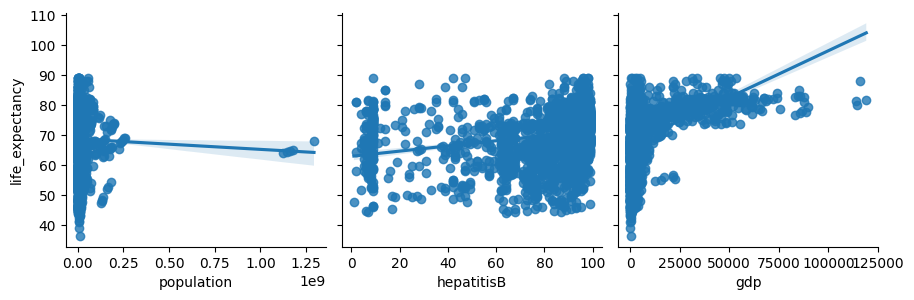

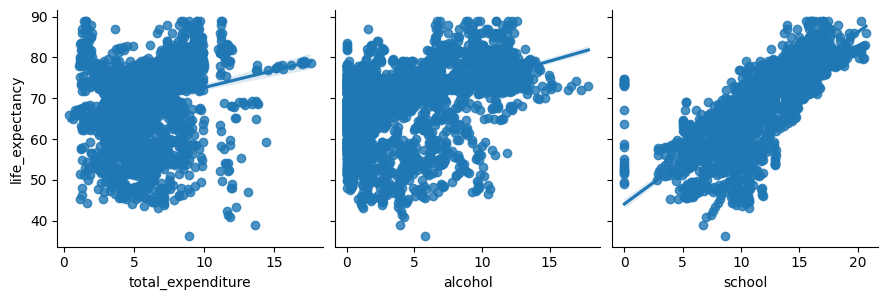

In [28]:
# Verificando outliers
dsa_get_pairs(df, alvo, atributos, 3)

## Detectando Valores Ausentes

In [29]:
# Visualizando o total de linhas por coluna
df.count()

country              2938
life_expectancy      2928
year                 2938
status               2938
adult_mortality      2928
inf_death            2938
alcohol              2744
hepatitisB           2385
measles              2938
bmi                  2904
polio                2919
diphtheria           2919
hiv                  2938
gdp                  2490
total_expenditure    2712
thinness_till19      2904
thinness_till9       2904
school               2775
population           2286
dtype: int64

In [30]:
# Extraindo o total de valores ausentes por coluna
valores_ausentes = df.isnull().sum().sort_values(ascending = False)

In [31]:
print(valores_ausentes)

population           652
hepatitisB           553
gdp                  448
total_expenditure    226
alcohol              194
school               163
thinness_till9        34
thinness_till19       34
bmi                   34
polio                 19
diphtheria            19
life_expectancy       10
adult_mortality       10
hiv                    0
measles                0
inf_death              0
status                 0
year                   0
country                0
dtype: int64


In [32]:
# Calculando o percentual de valores ausentes
valores_ausentes_percent = valores_ausentes[valores_ausentes > 0] / df.shape[0] 

In [33]:
print(f'{valores_ausentes_percent * 100} %')

population           22.191967
hepatitisB           18.822328
gdp                  15.248468
total_expenditure     7.692308
alcohol               6.603131
school                5.547992
thinness_till9        1.157250
thinness_till19       1.157250
bmi                   1.157250
polio                 0.646698
diphtheria            0.646698
life_expectancy       0.340368
adult_mortality       0.340368
dtype: float64 %


Qual Estratégia Adotar Para o Tratamento de Valores Ausentes?

Vamos discutir algumas opções no videobook do Capítulo 16.

## Detectando Outliers

Vamos começar olhando para as variáveis que têm o maior percentual de valores ausentes.

In [34]:
# Atributos com mais de 5% de valores missing
atributos = ['population', 'hepatitisB', 'gdp', 'total_expenditure', 'alcohol', 'school'] 

In [35]:
# Cria um novo dataframe
novo_dataframe = df[atributos]

In [36]:
# Identificação de outliers através do método do IQR (Interquartile Range)
Q1 = novo_dataframe.quantile(0.25)
Q3 = novo_dataframe.quantile(0.75)
IQR = Q3 - Q1

In [37]:
# Definir outliers como aqueles valores que estão fora do intervalo [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]
outliers = ((novo_dataframe < (Q1 - 1.5 * IQR)) | (novo_dataframe > (Q3 + 1.5 * IQR))).sum()

In [38]:
# Total de outliers
outliers

population           294
hepatitisB           254
gdp                  365
total_expenditure     32
alcohol                0
school                44
dtype: int64

In [39]:
# Cria um resumo com os outliers
outliers_summary = pd.DataFrame({'Outliers': outliers, 'Percentual': (outliers / len(novo_dataframe)) * 100})

In [40]:
# Retorna os resultados quando o valor for maior do que zero
outliers_summary[outliers_summary['Outliers'] > 0]

,Outliers,Percentual
population,294,10.006807
hepatitisB,254,8.645337
gdp,365,12.423417
total_expenditure,32,1.089176
school,44,1.497617


## Análise Estatística Para Tratamento de Outliers

In [41]:
# Definindo os limites para filtrar os outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

In [42]:
# Filtrando os outliers
novo_df = df[~((novo_dataframe < limite_inferior) | (novo_dataframe > limite_superior)).any(axis=1)]

Considerações Importantes:

- A regra do 1.5 IQR é um método comum para identificar outliers, mas não é uma regra rígida.
- A escolha do multiplicador (1.5) pode variar em diferentes contextos e conjuntos de dados.
- É importante analisar visualmente a distribuição dos dados para confirmar a presença de outliers e ajustar os limites, se necessário.
- Outras técnicas para identificar outliers podem ser utilizadas em conjunto com a regra do IQR.

In [43]:
# Shape
novo_df.shape

(2044, 19)

In [44]:
# Resumo estatístico
novo_df.describe()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
count,2036.000000,2044.000000,2036.000000,2044.000000,1908.000000,1653.000000,2044.000000,2032.000000,2041.000000,2041.000000,2044.000000,1668.000000,1883.000000,2032.000000,2032.000000,1910.000000,1.550000e+03
mean,68.261444,2007.516634,173.697937,21.272016,4.250854,88.543860,2043.051859,37.229429,83.469868,84.229789,1.906115,2603.414714,5.817047,4.973327,5.039813,11.779791,2.862564e+06
std,9.180601,4.620838,124.821601,75.877341,3.821064,11.667147,11166.996177,19.540099,22.293545,20.802376,5.353430,3051.987902,2.167468,4.070398,4.188165,2.893174,4.147575e+06
min,36.300000,2000.000000,1.000000,0.000000,0.010000,47.000000,0.000000,1.000000,3.000000,3.000000,0.100000,3.685949,0.370000,0.100000,0.100000,3.800000,3.400000e+01
25%,62.475000,2003.000000,83.750000,0.000000,0.847500,84.000000,0.000000,19.200000,78.000000,81.000000,0.100000,387.645945,4.380000,1.900000,1.900000,10.100000,1.413295e+05
50%,71.400000,2008.000000,154.000000,3.000000,3.400000,93.000000,10.000000,41.300000,93.000000,93.000000,0.100000,1312.038142,5.710000,3.550000,3.600000,12.100000,8.968025e+05
75%,74.700000,2012.000000,235.000000,17.000000,6.725000,97.000000,256.250000,54.900000,97.000000,97.000000,1.000000,3936.450613,7.130000,7.325000,7.400000,13.700000,3.712494e+06
max,89.000000,2015.000000,723.000000,1800.000000,17.310000,99.000000,212183.000000,87.300000,99.000000,99.000000,50.300000,13893.187680,12.250000,27.700000,28.600000,20.400000,1.789956e+07


In [45]:
# Valor máximo da população
novo_df.population.max()

np.float64(17899562.0)

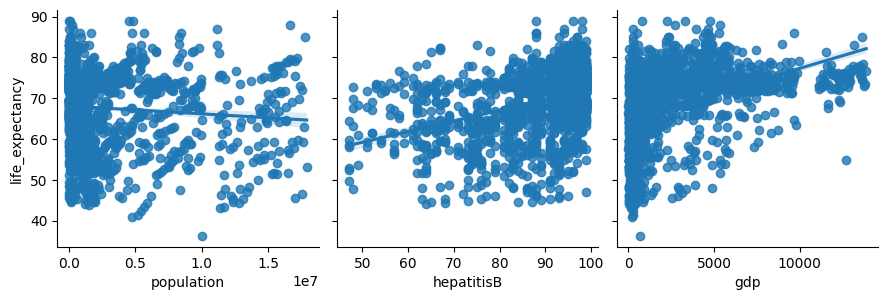

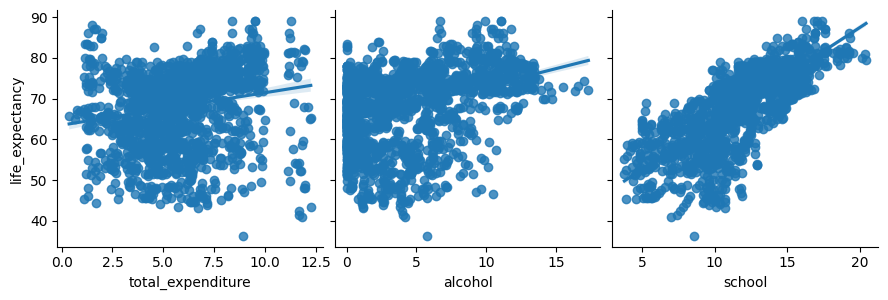

In [46]:
# Verificando outliers
dsa_get_pairs(novo_df, alvo, atributos, 3)

## Análise Estatística Para Tratamento de Valores Ausentes

In [47]:
# Verificando o total de valores ausentes
valores_ausentes = novo_df.isnull().sum().sort_values(ascending = False)

In [48]:
# Checando percentual de valores missing
valores_ausentes_percent = valores_ausentes[valores_ausentes > 0] / novo_df.shape[0] 
print(f'{valores_ausentes_percent * 100} %')

population           24.168297
hepatitisB           19.129159
gdp                  18.395303
total_expenditure     7.876712
alcohol               6.653620
school                6.555773
thinness_till9        0.587084
thinness_till19       0.587084
bmi                   0.587084
life_expectancy       0.391389
adult_mortality       0.391389
polio                 0.146771
diphtheria            0.146771
dtype: float64 %


In [49]:
# Função para o Replace das linhas vazias com a mediana
def impute_median(dados):
    return dados.fillna(dados.median())

In [50]:
novo_df.describe()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
count,2036.000000,2044.000000,2036.000000,2044.000000,1908.000000,1653.000000,2044.000000,2032.000000,2041.000000,2041.000000,2044.000000,1668.000000,1883.000000,2032.000000,2032.000000,1910.000000,1.550000e+03
mean,68.261444,2007.516634,173.697937,21.272016,4.250854,88.543860,2043.051859,37.229429,83.469868,84.229789,1.906115,2603.414714,5.817047,4.973327,5.039813,11.779791,2.862564e+06
std,9.180601,4.620838,124.821601,75.877341,3.821064,11.667147,11166.996177,19.540099,22.293545,20.802376,5.353430,3051.987902,2.167468,4.070398,4.188165,2.893174,4.147575e+06
min,36.300000,2000.000000,1.000000,0.000000,0.010000,47.000000,0.000000,1.000000,3.000000,3.000000,0.100000,3.685949,0.370000,0.100000,0.100000,3.800000,3.400000e+01
25%,62.475000,2003.000000,83.750000,0.000000,0.847500,84.000000,0.000000,19.200000,78.000000,81.000000,0.100000,387.645945,4.380000,1.900000,1.900000,10.100000,1.413295e+05
50%,71.400000,2008.000000,154.000000,3.000000,3.400000,93.000000,10.000000,41.300000,93.000000,93.000000,0.100000,1312.038142,5.710000,3.550000,3.600000,12.100000,8.968025e+05
75%,74.700000,2012.000000,235.000000,17.000000,6.725000,97.000000,256.250000,54.900000,97.000000,97.000000,1.000000,3936.450613,7.130000,7.325000,7.400000,13.700000,3.712494e+06
max,89.000000,2015.000000,723.000000,1800.000000,17.310000,99.000000,212183.000000,87.300000,99.000000,99.000000,50.300000,13893.187680,12.250000,27.700000,28.600000,20.400000,1.789956e+07


In [51]:
# Removendo valores missing (observe as diferentes formas de notação do lado esquerdo do sinal de igual)
novo_df.loc[:,'population'] = novo_df['population'].transform(impute_median)
novo_df.hepatitisB = novo_df['hepatitisB'].transform(impute_median)
novo_df.alcohol = novo_df['alcohol'].transform(impute_median)
novo_df.total_expenditure = novo_df['total_expenditure'].transform(impute_median)
novo_df.gdp = novo_df['gdp'].transform(impute_median)
novo_df.school = novo_df['school'].transform(impute_median)

In [52]:
# Verificando o total de valores ausentes
valores_ausentes = novo_df.isnull().sum().sort_values(ascending = False)

In [53]:
# Checando percentual de valores missing
valores_ausentes_percent = valores_ausentes[valores_ausentes > 0] / novo_df.shape[0] 
print(f'{valores_ausentes_percent * 100} %')

bmi                0.587084
thinness_till9     0.587084
thinness_till19    0.587084
adult_mortality    0.391389
life_expectancy    0.391389
diphtheria         0.146771
polio              0.146771
dtype: float64 %


In [54]:
# Remove registros com valores nulos
novo_df.dropna(inplace = True)

In [55]:
# Verificando o total de valores ausentes
valores_ausentes = novo_df.isnull().sum().sort_values(ascending = False)

In [56]:
# Checando percentual de valores missing
valores_ausentes_percent = valores_ausentes[valores_ausentes > 0] / novo_df.shape[0] 
print(f'{valores_ausentes_percent * 100} %')

Series([], dtype: float64) %


In [57]:
# Shape
novo_df.shape

(2023, 19)

In [58]:
novo_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2023 entries, 1 to 2937
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            2023 non-null   object 
 1   life_expectancy    2023 non-null   float64
 2   year               2023 non-null   int64  
 3   status             2023 non-null   object 
 4   adult_mortality    2023 non-null   float64
 5   inf_death          2023 non-null   int64  
 6   alcohol            2023 non-null   float64
 7   hepatitisB         2023 non-null   float64
 8   measles            2023 non-null   int64  
 9   bmi                2023 non-null   float64
 10  polio              2023 non-null   float64
 11  diphtheria         2023 non-null   float64
 12  hiv                2023 non-null   float64
 13  gdp                2023 non-null   float64
 14  total_expenditure  2023 non-null   float64
 15  thinness_till19    2023 non-null   float64
 16  thinness_till9     2023 non-n

Usaremos indicadores socioeconômicos independentes de identificação do país. Vamos remover as variáveis categóricas.

In [59]:
# Drop das variáveis
novo_df.drop(['country', 'status'], axis = 1, inplace = True)

In [60]:
# Shape do dataset original
df_dsa.shape

(2938, 22)

In [61]:
# Shape do dataset após a limpeza
novo_df.shape

(2023, 17)

## Engenharia de Recursos (Feature Engineering)

> Como há diferença muito grande de população entre os países usar essa variável pode ser arriscado. Vamos criar uma nova variável e categorizar os países em uma de 3 faixas possíveis de população.

In [62]:
novo_df.head()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
1,59.9,2014,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0
3,59.5,2012,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0
4,59.2,2011,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0
5,58.8,2010,279.0,74,0.01,66.0,1989,16.7,66.0,66.0,0.1,553.328940,9.20,18.4,18.4,9.2,2883167.0
6,58.6,2009,281.0,77,0.01,63.0,2861,16.2,63.0,63.0,0.1,445.893298,9.42,18.6,18.7,8.9,284331.0


In [63]:
novo_df.population.min()

np.float64(34.0)

In [64]:
novo_df.population.max()

np.float64(17899562.0)

In [65]:
# Criamos os pontos de corte (cutoffs) com 2 percentis como referência
pontos_corte = [novo_df.population.quantile(0.33), novo_df.population.quantile(0.67)]

In [66]:
pontos_corte

[np.float64(656519.86), np.float64(1365811.6)]

In [67]:
# Criamos uma nova variável com todos os valores preenchidos com 1
novo_df['pop_size'] = 1

In [68]:
# Definimos a faixa onde a variável terá o valor 2
novo_df.loc[(novo_df.population < pontos_corte[1]) & (novo_df.population > pontos_corte[0]), 'pop_size'] = 2

In [69]:
# Definimos a faixa onde a variável terá o valor 3
novo_df.loc[novo_df.population >= pontos_corte[1], 'pop_size'] = 3

In [70]:
# Dataset
novo_df.head()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size
1,59.9,2014,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0,1
3,59.5,2012,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0,3
4,59.2,2011,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0,3
5,58.8,2010,279.0,74,0.01,66.0,1989,16.7,66.0,66.0,0.1,553.328940,9.20,18.4,18.4,9.2,2883167.0,3
6,58.6,2009,281.0,77,0.01,63.0,2861,16.2,63.0,63.0,0.1,445.893298,9.42,18.6,18.7,8.9,284331.0,1


In [71]:
novo_df.pop_size.value_counts()

pop_size
2    687
1    668
3    668
Name: count, dtype: int64

> As variáveis alcohol e bmi têm uma relação direta e natural. Vamos criar uma nova variável chamada life_style com a combinação dessas duas variáveis.

In [72]:
# Criando a nova variável
novo_df['lifestyle'] = 0
novo_df.lifestyle = novo_df['bmi'] * novo_df['alcohol']

In [73]:
novo_df.head()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
1,59.9,2014,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0,1,0.186
3,59.5,2012,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0,3,0.176
4,59.2,2011,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0,3,0.172
5,58.8,2010,279.0,74,0.01,66.0,1989,16.7,66.0,66.0,0.1,553.328940,9.20,18.4,18.4,9.2,2883167.0,3,0.167
6,58.6,2009,281.0,77,0.01,63.0,2861,16.2,63.0,63.0,0.1,445.893298,9.42,18.6,18.7,8.9,284331.0,1,0.162


In [74]:
novo_df.lifestyle.describe()

count    2023.000000
mean      178.996408
std       209.416553
min         0.018000
25%        18.140500
50%        95.323000
75%       257.394000
max      1036.869000
Name: lifestyle, dtype: float64

In [75]:
# Verifique se há valores ausentes
missing_values = novo_df.isnull().sum().sort_values(ascending = False)
missing_values

life_expectancy      0
hiv                  0
pop_size             0
population           0
school               0
thinness_till9       0
thinness_till19      0
total_expenditure    0
gdp                  0
diphtheria           0
year                 0
polio                0
bmi                  0
measles              0
hepatitisB           0
alcohol              0
inf_death            0
adult_mortality      0
lifestyle            0
dtype: int64

In [76]:
novo_df.dtypes

life_expectancy      float64
year                   int64
adult_mortality      float64
inf_death              int64
alcohol              float64
hepatitisB           float64
measles                int64
bmi                  float64
polio                float64
diphtheria           float64
hiv                  float64
gdp                  float64
total_expenditure    float64
thinness_till19      float64
thinness_till9       float64
school               float64
population           float64
pop_size               int64
lifestyle            float64
dtype: object

## Análise de Correlação Para Verificar Multicolinearidade

Queremos que as variáveis preditoras tenham uma alta correlação com a variável alvo, mas não queremos que as variáveis preditoras tenham alta correlação entre si. Se houver alta correlação entre as variáveis preditoras isso é chamado de multicolinearidade e fere uma das suposições da regressão.

A correlação é uma medida da relação entre as variáveis. O coeficiente de correlação é um valor de -1 a +1, sendo:

**-1 indica alta correlação negativa.**

**+1 indica ata correlação positiva.**

**0 indica que não há correlação.**

Correlação não implica causalidade. Por exemplo: Sempre que aumenta o consumo de sorvete aumenta a presença de tubarões na praia. Provavelmente ambos os eventos ocorrem no verão e estão correlacionados, mas isso não significa que um evento causa o outro. Para afirmar isso teríamos que fazer uma análise de causalidade.

In [77]:
# Correlação das variáveis numéricas no conjunto de dados
novo_df.corr()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
life_expectancy,1.000000,0.204556,-0.658916,-0.206443,0.342425,0.257860,-0.115350,0.557954,0.452564,0.483659,-0.573127,0.360736,0.175738,-0.433580,-0.429357,0.708272,-0.105317,-0.117333,0.441366
year,0.204556,1.000000,-0.091760,-0.059838,-0.066639,-0.003178,-0.064347,0.096763,0.147489,0.228939,-0.158820,0.170945,0.070267,-0.059353,-0.055950,0.219471,0.020981,0.013190,-0.017373
adult_mortality,-0.658916,-0.091760,1.000000,0.099370,-0.149204,-0.188950,0.035432,-0.366745,-0.228938,-0.221803,0.512978,-0.197863,-0.090963,0.299104,0.302507,-0.383901,0.096768,0.123785,-0.231128
inf_death,-0.206443,-0.059838,0.099370,1.000000,-0.127545,-0.122515,0.480129,-0.221948,-0.183569,-0.183910,0.039115,-0.120331,-0.121871,0.321487,0.354512,-0.214215,0.111901,0.111776,-0.156769
alcohol,0.342425,-0.066639,-0.149204,-0.127545,1.000000,0.193844,-0.045324,0.310448,0.187916,0.199958,-0.036268,0.289360,0.262657,-0.386629,-0.379482,0.464657,-0.007040,0.002445,0.878858
hepatitisB,0.257860,-0.003178,-0.188950,-0.122515,0.193844,1.000000,-0.043089,0.115409,0.393191,0.391270,-0.090390,0.167829,0.046093,-0.086406,-0.102546,0.263879,-0.056455,-0.028477,0.181579
measles,-0.115350,-0.064347,0.035432,0.480129,-0.045324,-0.043089,1.000000,-0.142187,-0.110853,-0.123043,0.024412,-0.065666,-0.101675,0.133515,0.137056,-0.089084,-0.005326,0.017013,-0.085123
bmi,0.557954,0.096763,-0.366745,-0.221948,0.310448,0.115409,-0.142187,1.000000,0.253961,0.273612,-0.244626,0.323198,0.200959,-0.541904,-0.550691,0.552766,-0.056945,-0.041854,0.599062
polio,0.452564,0.147489,-0.228938,-0.183569,0.187916,0.393191,-0.110853,0.253961,1.000000,0.676507,-0.143756,0.198453,0.141294,-0.166819,-0.166363,0.382712,-0.045542,-0.041742,0.219793
diphtheria,0.483659,0.228939,-0.221803,-0.183910,0.199958,0.391270,-0.123043,0.273612,0.676507,1.000000,-0.154179,0.222266,0.157976,-0.189487,-0.186992,0.430627,-0.035142,-0.035290,0.225132


In [78]:
# Filtrando a matriz de correlação
dfCorr = novo_df.corr()
df_filtro_1 = dfCorr[((dfCorr >= 0.3) | (dfCorr <= -0.3)) & (dfCorr != 1.000)]
df_filtro_1

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
life_expectancy,NaN,NaN,-0.658916,NaN,0.342425,NaN,NaN,0.557954,0.452564,0.483659,-0.573127,0.360736,NaN,-0.433580,-0.429357,0.708272,NaN,NaN,0.441366
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_mortality,-0.658916,NaN,NaN,NaN,NaN,NaN,NaN,-0.366745,NaN,NaN,0.512978,NaN,NaN,NaN,0.302507,-0.383901,NaN,NaN,NaN
inf_death,NaN,NaN,NaN,NaN,NaN,NaN,0.480129,NaN,NaN,NaN,NaN,NaN,NaN,0.321487,0.354512,NaN,NaN,NaN,NaN
alcohol,0.342425,NaN,NaN,NaN,NaN,NaN,NaN,0.310448,NaN,NaN,NaN,NaN,NaN,-0.386629,-0.379482,0.464657,NaN,NaN,0.878858
hepatitisB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.393191,0.391270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measles,NaN,NaN,NaN,0.480129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,0.557954,NaN,-0.366745,NaN,0.310448,NaN,NaN,NaN,NaN,NaN,NaN,0.323198,NaN,-0.541904,-0.550691,0.552766,NaN,NaN,0.599062
polio,0.452564,NaN,NaN,NaN,NaN,0.393191,NaN,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,0.382712,NaN,NaN,NaN
diphtheria,0.483659,NaN,NaN,NaN,NaN,0.391270,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,NaN,0.430627,NaN,NaN,NaN


As variáveis adult_mortality, alcohol, bmi, polio, diphtheria, hiv, gdp, thinness_till19, thinness_till9, school e lifestyle atendem ao nosso critério. São as variáveis preditoras com maior correlação com a variável alvo.

Agora devemos checar uma das suposições da Regressão Linear e identificar possíveis problemas de multicolinearidade (alta correlação entre as variáveis preditoras). Com base nesse critério eliminamos uma de duas variáveis preditoras altamente correlacionadas. Vamos considerar 0.65 como marca de corte. Vamos filtrar mais uma vez a matriz de correlação.

In [79]:
# Filtrando a matriz de correlação
dfCorr = novo_df.corr()
df_filtro_2 = dfCorr[((dfCorr >= 0.65) | (dfCorr <= -0.65)) & (dfCorr != 1.000)]
df_filtro_2 = df_filtro_2.drop('life_expectancy', axis=1)
df_filtro_2 = df_filtro_2.drop('life_expectancy', axis=0)
df_filtro_2

,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_mortality,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inf_death,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.878858
hepatitisB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
polio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diphtheria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hiv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observe a alta correlação entre algumas variáveis preditoras.

Se preferir visualizar as correlações de forma gráfica, aqui está um exemplo de Pair Plot.

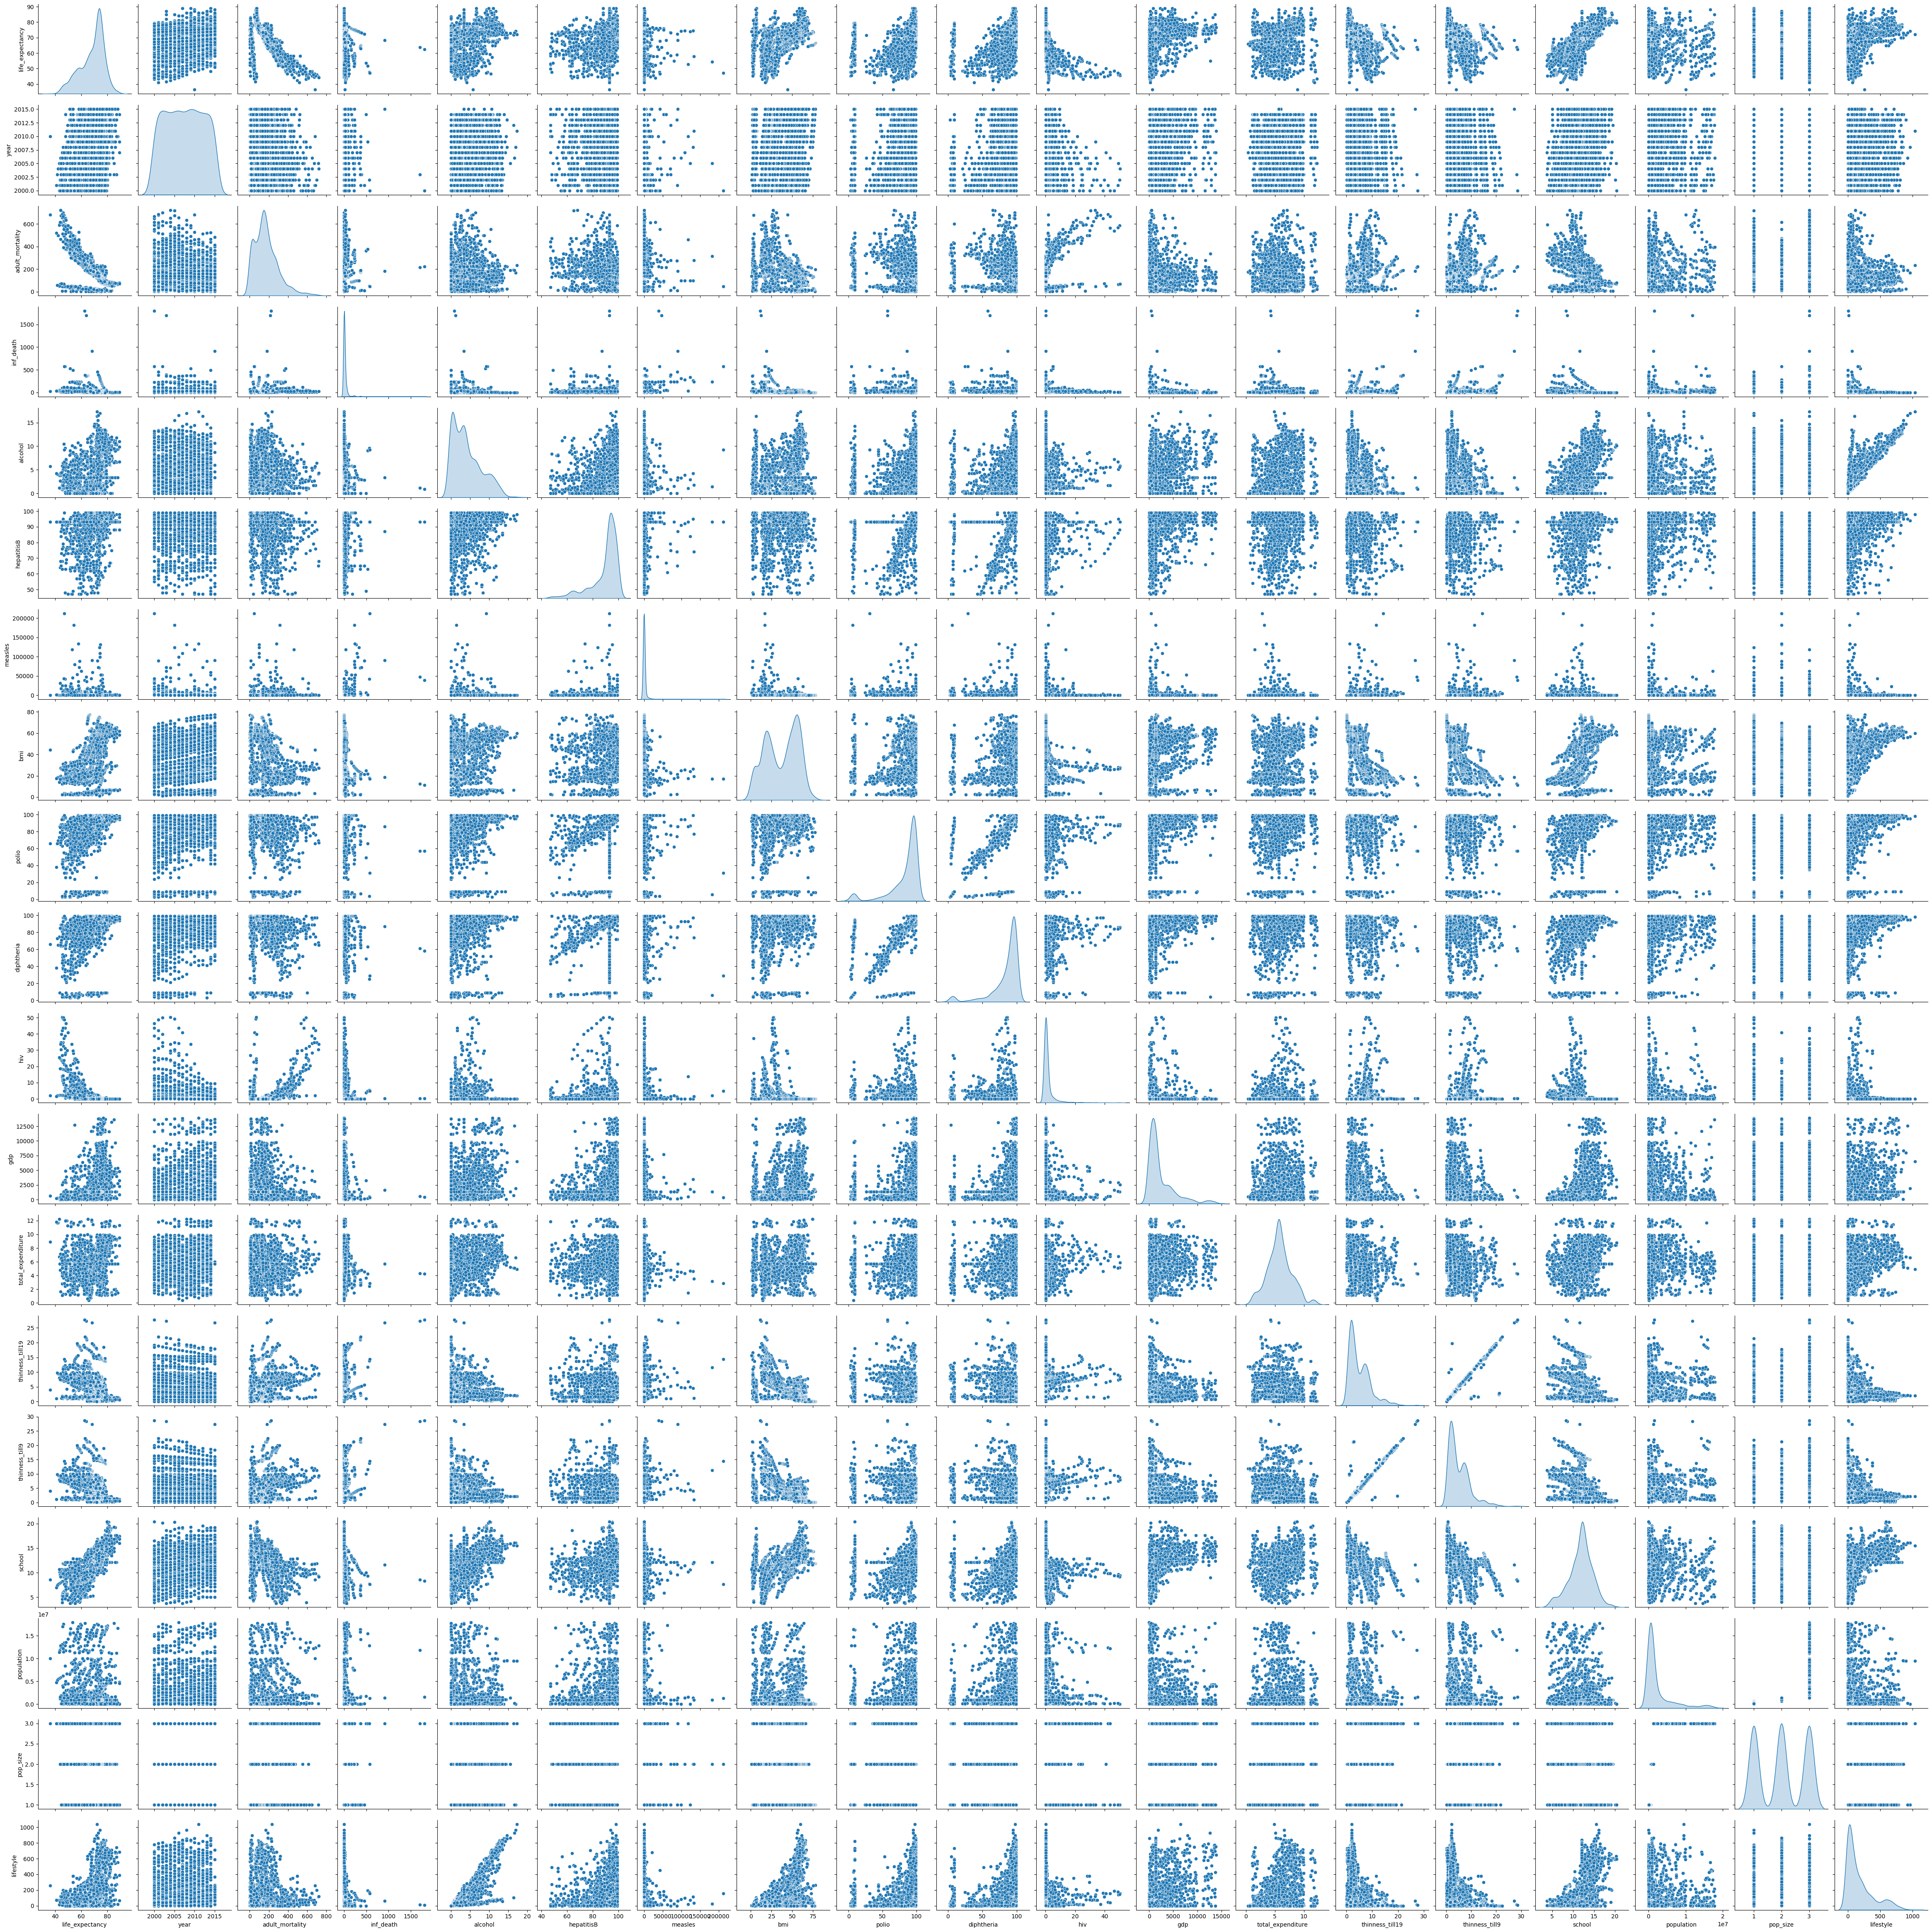

In [80]:
# Checando a correlação entre as variáveis
sns.pairplot(novo_df, diag_kind = "kde", height = 2.5);

### Decisão

**Primeiro Filtro - Correlação com a Variável Alvo**

As variáveis adult_mortality, alcohol, bmi, polio, diphtheria, hiv, gdp, thinness_till19, thinness_till9, school e lifestyle atendem ao nosso primeiro critério. São as variáveis preditoras com maior correlação com a variável alvo.

**Segundo Filtro - Multicolinearidade**

Com base no filtro de multicolinearidade, as variáveis adult_mortality, diphtheria, hiv, gdp, thinness_till19, school e lifestyle serão as variáveis mantidas para a modelagem estatística.

**Terceiro Filtro - Compreensão dos Dados, do Problema de Negócio e Entrega dos Resultados**

Embora a variável bmi tenha maior correlação com a variável alvo do que a variável lifestyle, esta segunda carrega informação de duas variáveis (alcohol e bmi). Por essa razão, vamos descartar a variável bmi e manter a variável lifestyle. Isso também evita alguma multicolinearidade entre as duas variáveis, além de facilitar a entrega do resulltado ao tomador de decisão.

Nota: Manter a variável bmi ao invés da variável lifestyle também é uma decisão válida! Fizemos isso e a conclusão da modelagem estatística é a mesma!

In [81]:
# Preparando o novo dataset
novo_df_final = pd.DataFrame({'life_expectancy': novo_df['life_expectancy'],
                              'adult_mortality': novo_df['adult_mortality'],
                              'diphtheria': novo_df['diphtheria'],
                              'hiv': novo_df['hiv'],
                              'gdp': novo_df['gdp'],
                              'thinness_till19': novo_df['thinness_till19'],
                              'school': novo_df['school'],
                              'lifestyle': novo_df['lifestyle'],})

In [82]:
novo_df_final.head()

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school,lifestyle
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0,0.186
3,59.5,272.0,67.0,0.1,669.959000,17.9,9.8,0.176
4,59.2,275.0,68.0,0.1,63.537231,18.2,9.5,0.172
5,58.8,279.0,66.0,0.1,553.328940,18.4,9.2,0.167
6,58.6,281.0,63.0,0.1,445.893298,18.6,8.9,0.162


In [83]:
# Verifique se há valores ausentes
missing_values = novo_df_final.isnull().sum().sort_values(ascending = False)
missing_values

life_expectancy    0
adult_mortality    0
diphtheria         0
hiv                0
gdp                0
thinness_till19    0
school             0
lifestyle          0
dtype: int64

In [84]:
# Visualizando o total de linhas por coluna
novo_df_final.count()

life_expectancy    2023
adult_mortality    2023
diphtheria         2023
hiv                2023
gdp                2023
thinness_till19    2023
school             2023
lifestyle          2023
dtype: int64

In [85]:
# Checando multicolinearidade e removendo varáveis altamente correlacionadas
corr_map = novo_df_final.corr()
corr_map

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school,lifestyle
life_expectancy,1.000000,-0.658916,0.483659,-0.573127,0.360736,-0.433580,0.708272,0.441366
adult_mortality,-0.658916,1.000000,-0.221803,0.512978,-0.197863,0.299104,-0.383901,-0.231128
diphtheria,0.483659,-0.221803,1.000000,-0.154179,0.222266,-0.189487,0.430627,0.225132
hiv,-0.573127,0.512978,-0.154179,1.000000,-0.118378,0.212890,-0.232993,-0.132152
gdp,0.360736,-0.197863,0.222266,-0.118378,1.000000,-0.211979,0.460247,0.333733
thinness_till19,-0.433580,0.299104,-0.189487,0.212890,-0.211979,1.000000,-0.424922,-0.449094
school,0.708272,-0.383901,0.430627,-0.232993,0.460247,-0.424922,1.000000,0.528939
lifestyle,0.441366,-0.231128,0.225132,-0.132152,0.333733,-0.449094,0.528939,1.000000


In [86]:
# Função para o plot da matriz de correlação
def CorrMat(df, dropDuplicates = True, xrot = 70, yrot = 0, label = 'Variable'):

    # Excluir correlações duplicadas mascarando os valores superiores à direita
    if dropDuplicates:
        mask = np.zeros_like(df, dtype = bool)
        mask[np.triu_indices_from(mask)] = True

    # Definir cor do plano de fundo / estilo do gráfico
    sns.set_style(style = 'dark')
    fig, ax = plt.subplots(figsize = (8, 8))

    # Adiciona mapa de cores do vermelho ao azul
    plt.title("Matriz de Correlação")

    # Desenha gráfico de correlação com ou sem duplicatas
    if dropDuplicates:
        sns.heatmap(df, mask = mask, square = True, linewidth = .5, cbar_kws = {"shrink": .5}, ax = ax)
        plt.xlabel(label)
        plt.ylabel(label)
        plt.xticks(rotation=xrot)
        plt.yticks(rotation=yrot)

    else:
        sns.heatmap(df, square = True, linewidth = .5, cbar_kws = {"shrink": .5}, ax = ax)
        plt.xlabel(label)
        plt.ylabel(label)
        plt.xticks(rotation = xrot)
        plt.yticks(rotation = yrot)
    return

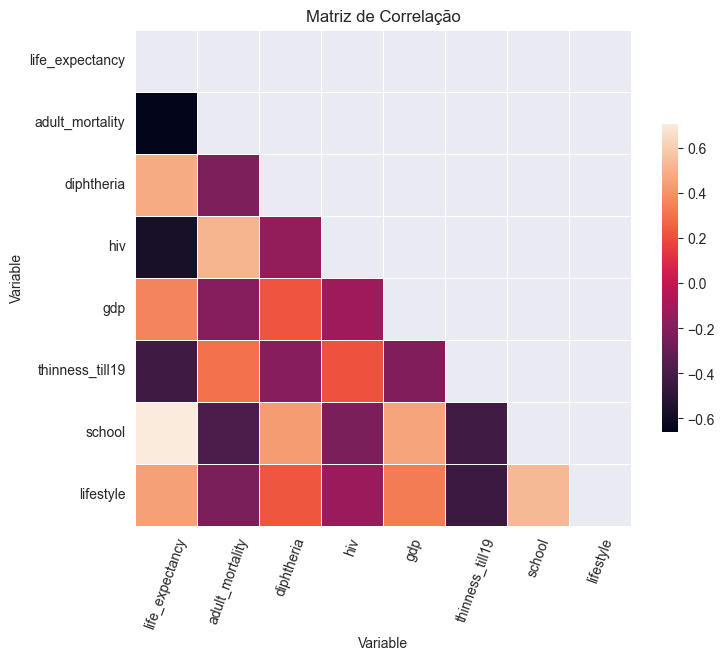

In [87]:
# Plot da matriz de correlação
CorrMat(corr_map)

In [88]:
# Dataset
novo_df_final.head()

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school,lifestyle
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0,0.186
3,59.5,272.0,67.0,0.1,669.959000,17.9,9.8,0.176
4,59.2,275.0,68.0,0.1,63.537231,18.2,9.5,0.172
5,58.8,279.0,66.0,0.1,553.328940,18.4,9.2,0.167
6,58.6,281.0,63.0,0.1,445.893298,18.6,8.9,0.162


In [89]:
# Dataset
novo_df_final.dtypes

life_expectancy    float64
adult_mortality    float64
diphtheria         float64
hiv                float64
gdp                float64
thinness_till19    float64
school             float64
lifestyle          float64
dtype: object

In [90]:
novo_df_final.shape

(2023, 8)

### Modelagem Estatística

A modelagem estatística envolve a construção de modelos matemáticos que capturam as relações entre variáveis em um conjunto de dados. Esses modelos são então usados para entender como as variáveis estão relacionadas, a fim de tomar decisões informadas baseadas em análises. Aqui estão alguns pontos-chave sobre a modelagem estatística:

Componentes da Modelagem Estatística:

**Variáveis e Dados**: Coleção de dados que inclui a variável dependente (o que você quer explicar ou prever) e as variáveis independentes (fatores que você acredita que influenciam a variável dependente).

**Modelo Matemático**: Uma representação simplificada da realidade que expressa relações matemáticas entre variáveis. Os modelos podem variar de simples (como regressão linear) a complexos (como redes neurais).

**Estimação de Parâmetros**: O processo de ajuste do modelo aos dados, frequentemente usando métodos como o de Mínimos Quadrados Ordinários (OLS) para encontrar os valores dos parâmetros do modelo que melhor se ajustam aos dados observados.

**Diagnóstico e Validação**: Avaliação do modelo para verificar sua adequação, incluindo a análise dos resíduos, verificação de suposições e, possivelmente, a modificação do modelo para melhorar seu desempenho.

In [91]:
# Variável alvo x Variáveis Preditoras
formula = 'life_expectancy ~ adult_mortality + diphtheria + hiv + gdp + thinness_till19 + school + lifestyle'

In [92]:
# Cria e treina o modelo
modelo_v1 = ols(formula, data = novo_df_final).fit()

In [93]:
# Coeficiente de Determinação
print(f"R-squared: {modelo_v1.rsquared}")

R-squared: 0.7737705044839867


In [94]:
# Coeficientes
print(f"Coeficientes:\n{modelo_v1.params}")

Coeficientes:
Intercept          51.016574
adult_mortality    -0.021286
diphtheria          0.079267
hiv                -0.484974
gdp                 0.000062
thinness_till19    -0.127453
school              1.289512
lifestyle           0.002567
dtype: float64


In [95]:
modelo_v1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     984.6
Date:                Tue, 29 Jul 2025   Prob (F-statistic):               0.00
Time:                        10:20:03   Log-Likelihood:                -5852.1
No. Observations:                2023   AIC:                         1.172e+04
Df Residuals:                    2015   BIC:                         1.177e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          51.0166      0.667     76.474      0.000      49.708      52.325
adult_mortality    -0.0213      0.001    -22.068      0.000      -0.023      -0.019
diphtheria          0.0793      0.005     15.252      0.000       0.069       0.089
hiv                -0.4850      0.021    -22.928      0.000      -0.526      -0.443
gdp              6.181e-05   3.93e-05      1.574      0.116   -1.52e-05       0.000
thinness_till19    -0.1275      0.028     -4.546      0.000      -0.182      -0.072
school              1.2895      0.049     26.065      0.000       1.192       1.387
lifestyle           0.0026      0.001      4.451      0.000       0.001       0.004
==============================================================================
Omnibus:                      105.060   Durbin-Watson:                   0.675
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              194.134
Skew:                          -0.383   Prob(JB):                     6.99e-43
Kurtosis:                       4.310   Cond. No.                     2.53e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.53e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

> A variável gdp apresenta um valor-p superior a 0.05 e, portanto, não é estatisticamente significativa para explicar a variável alvo. Vamos removê-la.

In [96]:
# Segunda versão do modelo de regressão
formula = 'life_expectancy ~ adult_mortality + diphtheria + hiv + thinness_till19 + school + lifestyle'
modelo_v2 = ols(formula, data = novo_df_final).fit()
modelo_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     1147.
Date:                Tue, 29 Jul 2025   Prob (F-statistic):               0.00
Time:                        10:20:03   Log-Likelihood:                -5853.3
No. Observations:                2023   AIC:                         1.172e+04
Df Residuals:                    2016   BIC:                         1.176e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          50.8445      0.658     77.233      0.000      49.553      52.136
adult_mortality    -0.0213      0.001    -22.094      0.000      -0.023      -0.019
diphtheria          0.0795      0.005     15.299      0.000       0.069       0.090
hiv                -0.4850      0.021    -22.922      0.000      -0.527      -0.444
thinness_till19    -0.1266      0.028     -4.515      0.000      -0.182      -0.072
school              1.3132      0.047     27.859      0.000       1.221       1.406
lifestyle           0.0027      0.001      4.671      0.000       0.002       0.004
==============================================================================
Omnibus:                      108.281   Durbin-Watson:                   0.676
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              199.828
Skew:                          -0.394   Prob(JB):                     4.05e-44
Kurtosis:                       4.323   Cond. No.                     2.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

> Observe a nota 2 acima. Parace haver multicolinearidade nos preditores. Podemos voltar e rever nosso critério de decisão e remover variáveis que estejam com correlação acima de 0.55, por exemplo (ao invés de usar 0.65 como usamos antes). Mas antes disso, vamos padronizar os dados e colocar tudo na mesma escala e avaliar o resultado.

In [97]:
# Variáveis que serão padronizadas
atributos = ['adult_mortality', 'diphtheria', 'hiv', 'thinness_till19', 'school', 'lifestyle'] 

In [98]:
# Padronização
scaler = StandardScaler()
scaler.fit(novo_df_final[atributos])
scaled_features = scaler.transform(novo_df_final[atributos])

In [99]:
# Criando um dataframe com dados padronizados
scaled_features_df = pd.DataFrame(scaled_features, columns = atributos, index = novo_df_final.index)
scaled_features_df.head()

,adult_mortality,diphtheria,hiv,thinness_till19,school,lifestyle
1,0.784288,-1.070929,-0.337999,3.076510,-0.658477,-0.854062
3,0.792299,-0.830592,-0.337999,3.174831,-0.730539,-0.854109
4,0.816331,-0.782525,-0.337999,3.248572,-0.838631,-0.854128
5,0.848374,-0.878660,-0.337999,3.297732,-0.946724,-0.854152
6,0.864395,-1.022861,-0.337999,3.346893,-1.054817,-0.854176


In [100]:
# Terceira versão do modelo
modelo_v3 = sm.OLS(endog = novo_df_final['life_expectancy'], 
                   exog = sm.add_constant(scaled_features_df.values)).fit()

In [101]:
modelo_v3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     1147.
Date:                Tue, 29 Jul 2025   Prob (F-statistic):               0.00
Time:                        10:20:03   Log-Likelihood:                -5853.3
No. Observations:                2023   AIC:                         1.172e+04
Df Residuals:                    2016   BIC:                         1.176e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.3059      0.097    702.041      0.000      68.115      68.497
x1            -2.6608      0.120    -22.094      0.000      -2.897      -2.425
x2             1.6541      0.108     15.299      0.000       1.442       1.866
x3            -2.6080      0.114    -22.922      0.000      -2.831      -2.385
x4            -0.5151      0.114     -4.515      0.000      -0.739      -0.291
x5             3.6447      0.131     27.859      0.000       3.388       3.901
x6             0.5602      0.120      4.671      0.000       0.325       0.795
==============================================================================
Omnibus:                      108.281   Durbin-Watson:                   0.676
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              199.828
Skew:                          -0.394   Prob(JB):                     4.05e-44
Kurtosis:                       4.323   Cond. No.                         2.56
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Interpretação do Modelo Final

Acompanhe a análise no videobook do Capítulo 17.

## Entrega do Resultado Para o Tomador de Decisão

Ao comunicar os resultados dessa análise aos tomadores de decisão, é importante focar em informações chave que são relevantes para a tomada de decisão, simplificando a linguagem técnica e destacando implicações práticas. Aqui está uma sugestão de como você pode entregar o resultado da sua análise.

___

**Resumo da Análise de Expectativa de Vida**

Nossa análise utilizou um modelo estatístico para examinar como diversos fatores influenciam a expectativa de vida. Os resultados oferecem insights valiosos que podem orientar estratégias de saúde pública e alocação de recursos.

Principais Descobertas:

- Efetividade do Modelo: O modelo demonstrou ser bastante eficaz, explicando cerca de 77% das variações na expectativa de vida. Isso indica um alto grau de precisão na nossa capacidade de prever a expectativa de vida com base nos fatores analisados.

Impacto dos Fatores de Saúde e Estilo de Vida:

- Mortalidade Adulta e HIV: Como esperado, um aumento nos índices de mortalidade adulta e HIV está significativamente associado a uma diminuição na expectativa de vida. Estes resultados enfatizam a necessidade de continuar e reforçar os programas de saúde focados na redução da mortalidade e na luta contra o HIV.
- Educação e Estilo de Vida Saudável: Por outro lado, fatores positivos como níveis mais altos de educação e um estilo de vida saudável mostram uma associação forte com o aumento da expectativa de vida. Isso reforça a importância de investimentos em educação e promoção de estilos de vida saudáveis como parte integral das políticas de saúde pública.
- Vacinação e Nutrição: A análise também destacou a importância da vacinação (como a contra difteria) e da boa nutrição (indicada pela menor prevalência de magreza entre crianças e adolescentes) como fatores chave para a melhoria da expectativa de vida.

Recomendações:

- Foco em Prevenção: Reforçar programas de prevenção e tratamento para doenças críticas como HIV e melhorar a cobertura vacinal.
- Educação para Saúde: Investir em educação como um meio de promover estilos de vida saudáveis e melhorar os indicadores de saúde da população.
- Monitoramento e Avaliação: Continuar a monitorar esses fatores de saúde e ajustar as políticas públicas conforme necessário para atender às necessidades emergentes da população.

Conclusão:

Este estudo reafirma a importância de não apenas combater doenças, mas também de promover educação e estilos de vida saudáveis. As descobertas oferecem uma base sólida para decisões informadas que podem levar a melhorias significativas na saúde e na longevidade da população.

___

Este resumo destila as informações técnicas em pontos chave, tornando-os acessíveis para um público não especializado, ao mesmo tempo em que fornece recomendações claras baseadas em evidências para ação.

Trabalho concluído, projeto entregue, cliente feliz, partimos para o próximo projeto! 

Até o próximo capítulo!

In [102]:
%reload_ext watermark
%watermark -a "Data Science Academy"

Author: Data Science Academy



In [103]:
#%watermark -v -m

In [104]:
#%watermark --iversions

# Fim